## =======================================================================

## Persiapan Library (Install & Import)

#### Install Library | Sklearn | Pandas | WorkCloud | Matplotlib | Numpy

In [ ]:
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install seaborn
%pip install scikit-learn
%pip install wordcloud

#### Import Library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings as warning

## =======================================================================

## Data Cleaning | Intro Dataset
#### Sumber: https://www.kaggle.com/datasets/lainguyn123/student-performance-factors/data

#### Open Dataset | Check Missing Values | Handle Missing Values | Check Duplicate | Display Head & Tail Dataset

In [32]:
#Open Dataset
student = pd.read_csv("StudentPerformanceFactors.csv")

#Check Missing Values
missing_values = student.isnull().sum()

#Check Modus | Nilai Sering banyak muncul
modus = student.mode().iloc[0]

#Isi Missing Values dengan Modus
student_fix = student.fillna(modus)

#Jumlah Baris dan Kolom
baris,kolom = student_fix.shape
print(f"Jumlah Baris : {baris} dan Jumlah Kolom : {kolom}")

#Check Duplicate
duplicate = student.duplicated().sum()
print(f"Total Data Duplicate: {duplicate}")

#Head (Atas)
display(student_fix.head(5))

#Tail (Bawah)
display(student_fix.tail(5))

Jumlah Baris : 6607 dan Jumlah Kolom : 20
Total Data Duplicate: 0


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68
6606,15,67,Medium,Low,Yes,9,94,Medium,Yes,0,Medium,Medium,Public,Positive,4,No,Postgraduate,Near,Male,64


#### Cek Kolom Kategorial dan Numerik

In [33]:
#Cek Kolom Kategorial dan Number
number_column = list(student_fix.select_dtypes(include=["int64"]).columns)
kategori_column = list(student_fix.select_dtypes(include=["object"]).columns)
display(number_column)
display(kategori_column)
warning.filterwarnings('ignore')

for kat in kategori_column:
    print("============================")
    print(student_fix[kat].value_counts())

['Hours_Studied',
 'Attendance',
 'Sleep_Hours',
 'Previous_Scores',
 'Tutoring_Sessions',
 'Physical_Activity',
 'Exam_Score']

['Parental_Involvement',
 'Access_to_Resources',
 'Extracurricular_Activities',
 'Motivation_Level',
 'Internet_Access',
 'Family_Income',
 'Teacher_Quality',
 'School_Type',
 'Peer_Influence',
 'Learning_Disabilities',
 'Parental_Education_Level',
 'Distance_from_Home',
 'Gender']

Parental_Involvement
Medium    3362
High      1908
Low       1337
Name: count, dtype: int64
Access_to_Resources
Medium    3319
High      1975
Low       1313
Name: count, dtype: int64
Extracurricular_Activities
Yes    3938
No     2669
Name: count, dtype: int64
Motivation_Level
Medium    3351
Low       1937
High      1319
Name: count, dtype: int64
Internet_Access
Yes    6108
No      499
Name: count, dtype: int64
Family_Income
Low       2672
Medium    2666
High      1269
Name: count, dtype: int64
Teacher_Quality
Medium    4003
High      1947
Low        657
Name: count, dtype: int64
School_Type
Public     4598
Private    2009
Name: count, dtype: int64
Peer_Influence
Positive    2638
Neutral     2592
Negative    1377
Name: count, dtype: int64
Learning_Disabilities
No     5912
Yes     695
Name: count, dtype: int64
Parental_Education_Level
High School     3313
College         1989
Postgraduate    1305
Name: count, dtype: int64
Distance_from_Home
Near        3951
Moderate    1998
Far          

## Glosarium Variabel Target

Di dalam pengembangan sistem prediksi ini, penelitian berfokus pada dua bentuk luaran (*output*) siswa yang mewakili aspek kognitif dan aspek psikologis/perilaku. Berikut adalah detail dari kedua variabel target ($Y$) yang digunakan:

### 1. `Exam_Score` (Nilai Ujian Akhir)
* **Definisi:** Variabel numerik kontinu (*continuous numeric variable*) yang merepresentasikan capaian nilai mentah (*raw score*) hasil ujian akhir seorang siswa dalam rentang skala **0 hingga 100**.
* **Peran dalam Model:** Bertindak sebagai **Variabel Target ($Y$)** pada pemodelan regresi (*Linear Regression*).
* **Interpretasi Skala:**
  * Semakin mendekati angka 100, nilai ini mengindikasikan tingkat penguasaan materi akademis dan performa kognitif siswa yang semakin sempurna.
  * Perubahan nilai pada variabel ini diprediksi secara langsung oleh model menggunakan beberapa fitur yang akan dijabarkan pada langkah - langkah berikutnya

---

### 2. `Motivation_Level` (Tingkat Motivasi Belajar)
* **Definisi:** Variabel kategorial ordinal (*ordinal categorical variable*) yang merepresentasikan derajat dorongan psikologis, dan komitmen siswa dalam mengikuti proses pembelajaran.
* **Peran dalam Model:** Bertindak sebagai **Variabel Target ($Y$)** pada pemodelan klasifikasi (*Logistic Regression*).
* **Interpretasi Nilai (Setelah Proses Encoding):**
  * **`0` - Low (Rendah):** Menunjukkan minimnya inisiatif belajar, keterlibatan kelas yang pasif, dan tingginya risiko penurunan performa akademis. Siswa pada kategori ini memerlukan perhatian, intervensi, atau konseling khusus dari pengajar.
  * **`1` - Medium (Sedang):** Menunjukkan tingkat komitmen yang stabil namun cenderung berada di zona nyaman. Siswa memiliki dorongan belajar yang cukup untuk memenuhi standar kelulusan, tetapi belum mencapai batas potensi optimalnya.
  * **`2` - High (Tinggi):** Menunjukkan determinasi yang kuat, kemandirian belajar yang tinggi, serta keterlibatan aktif dalam ekosistem akademik. Siswa pada kategori ini sangat potensial untuk dilibatkan dalam program tutor.

## **Glosarium Fitur Independen (Fitur Tambahan)**

Berikut adalah penjelasan singkat untuk 18 atribut independen yang digunakan dalam dataset ini untuk menganalisis faktor-faktor yang memengaruhi performa akademik siswa:

1. **Hours_Studied** (`Numerik`): Jumlah jam yang dihabiskan siswa untuk belajar per minggu.
2. **Attendance** (`Numerik`): Persentase kehadiran siswa di kelas selama satu semester atau tahun ajaran.
3. **Parental_Involvement** (`Kategorial`): Tingkat keterlibatan orang tua dalam mendukung pendidikan anak (pilihan: *Low, Medium, High*).
4. **Access_to_Resources** (`Kategorial`): Ketersediaan dan kualitas fasilitas belajar pendukung seperti buku, internet, atau alat bantu lainnya (pilihan: *Low, Medium, High*).
5. **Extracurricular_Activities** (`Kategorial`): Status partisipasi siswa dalam kegiatan ekstrakurikuler di luar jam pelajaran wajib (pilihan: *Yes, No*).
6. **Sleep_Hours** (`Numerik`): Jumlah rata-rata jam tidur yang diperoleh siswa setiap malam.
7. **Previous_Scores** (`Numerik`): Nilai rata-rata atau skor ujian yang diperoleh siswa pada periode atau jenjang penilaian sebelumnya.
8. **Motivation_Level** (`Kategorial`): Tingkat motivasi internal dan semangat belajar yang dimiliki oleh siswa (pilihan: *Low, Medium, High*). *[Catatan: Digunakan juga sebagai target pada pemodelan klasifikasi]*.
9. **Internet_Access** (`Kategorial`): Ketersediaan akses jaringan internet yang memadai di rumah siswa untuk mendukung proses belajar (pilihan: *Yes, No*).
10. **Tutoring_Sessions** (`Numerik`): Jumlah sesi bimbingan belajar (les/privat) tambahan yang diikuti oleh siswa per bulan.
11. **Family_Income** (`Kategorial`): Klasifikasi tingkat pendapatan atau kondisi finansial keluarga siswa (pilihan: *Low, Medium, High*).
12. **Teacher_Quality** (`Kategorial`): Penilaian atau tingkat kualitas pengajaran dari guru yang mengajar siswa di kelas (pilihan: *Low, Medium, High*).
13. **School_Type** (`Kategorial`): Jenis institusi sekolah tempat siswa menempuh pendidikan (pilihan: *Public* / Sekolah Negeri atau *Private* / Sekolah Swasta).
14. **Peer_Influence** (`Kategorial`): Dampak atau pengaruh lingkungan pertemanan terhadap perilaku belajar siswa (pilihan: *Positive, Neutral, Negative*).
15. **Physical_Activity** (`Numerik`): Rata-rata jumlah jam per minggu yang dihabiskan siswa untuk berolahraga atau melakukan aktivitas fisik.
16. **Learning_Disabilities** (`Kategorial`): Indikasi apakah siswa memiliki hambatan atau gangguan belajar tertentu yang terdiagnosis (pilihan: *Yes, No*).
17. **Parental_Education_Level** (`Kategorial`): Tingkat pendidikan terakhir yang berhasil diselesaikan oleh orang tua siswa (pilihan: *High School, College, Postgraduate*).
18. **Distance_from_School** (`Kategorial`): Jarak geografis atau durasi perjalanan dari rumah menuju ke sekolah (pilihan: *Low, Medium, High*).

## =======================================================================

## EDA ( Exploratory Data Analysis )

#### Mean Median Modus Dari Tiap Kolom Dataset (Tipe Numerik)

In [34]:
student_fix.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


#### Pola Persebaran Tiap Kolom Bertipe Numerik

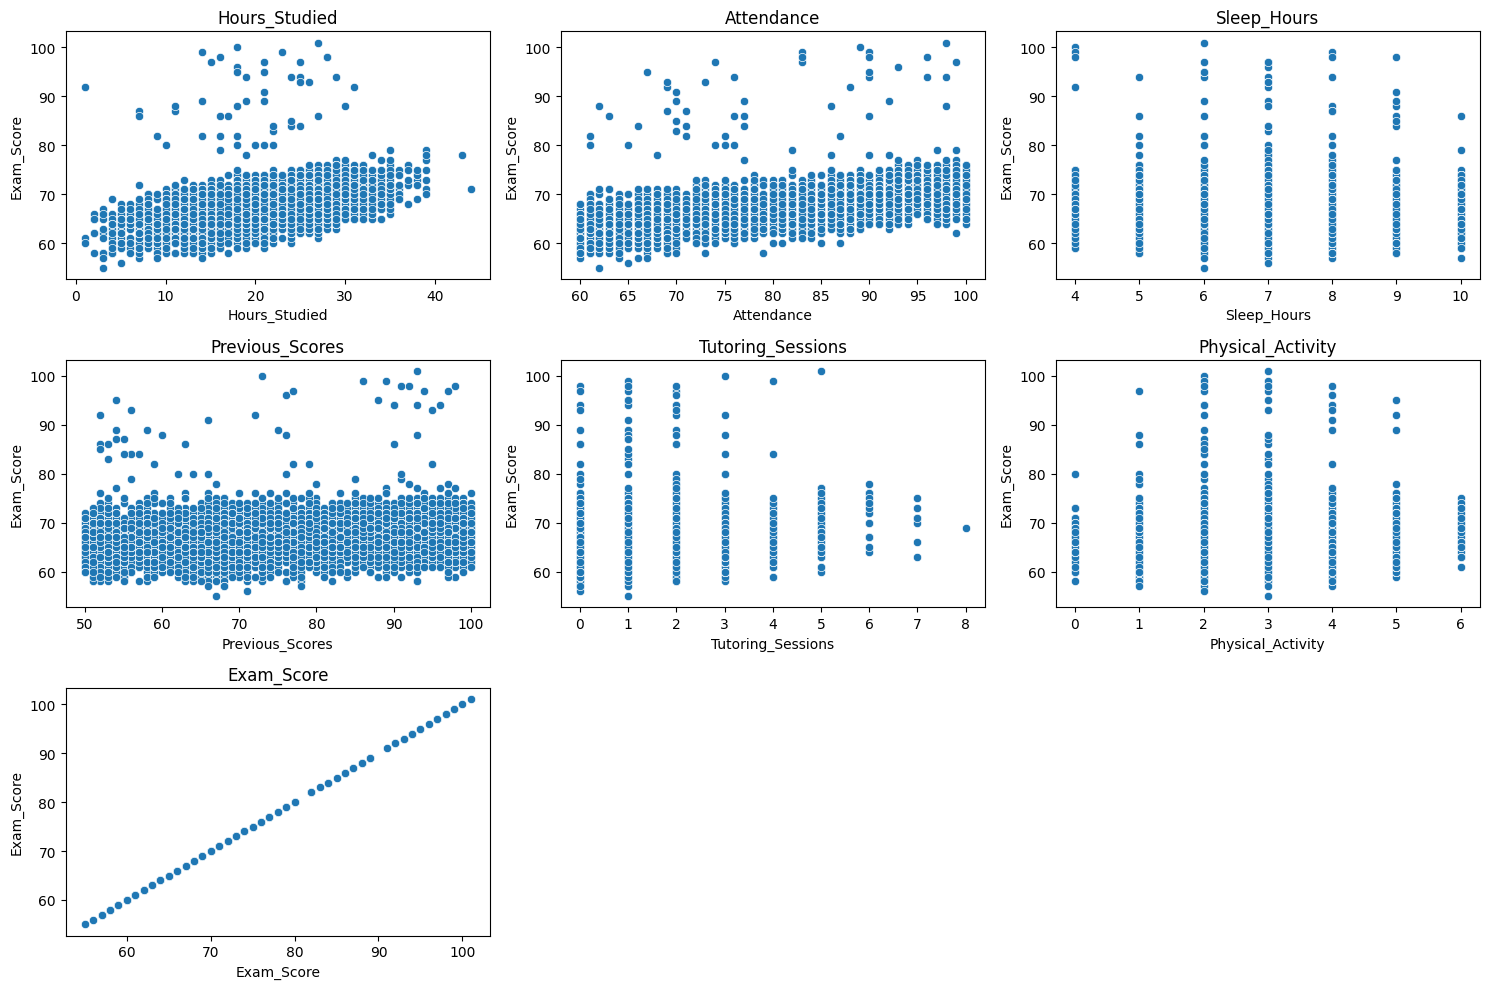

In [35]:
#Define Ukuran Plot
plt.figure(figsize=(15,10))
for i,col in enumerate(number_column,1):
    plt.subplot(3,3,i)
    sns.scatterplot(data=student_fix,x=col,y="Exam_Score")
    plt.title(col)
plt.tight_layout()
plt.show()

#### Insight
* **Hours studied dan Attendance** memainkan peran penting dalam memprediksi nilai akhir ujian
* **Previous_Scores** juga memainkan peran dalam memprediksi hasil akhir
* **Sleep_Hours, Tutoring_Sessions, dan Physical_Activity** tidak menimbulkan dampak yang besar
* Bagian **Exam_Score** pola persebarannya linear sehingga cocok jika digunakan sebagai taget / label

#### Distribusi Nilai dari Tiap Tipe Data Numerik

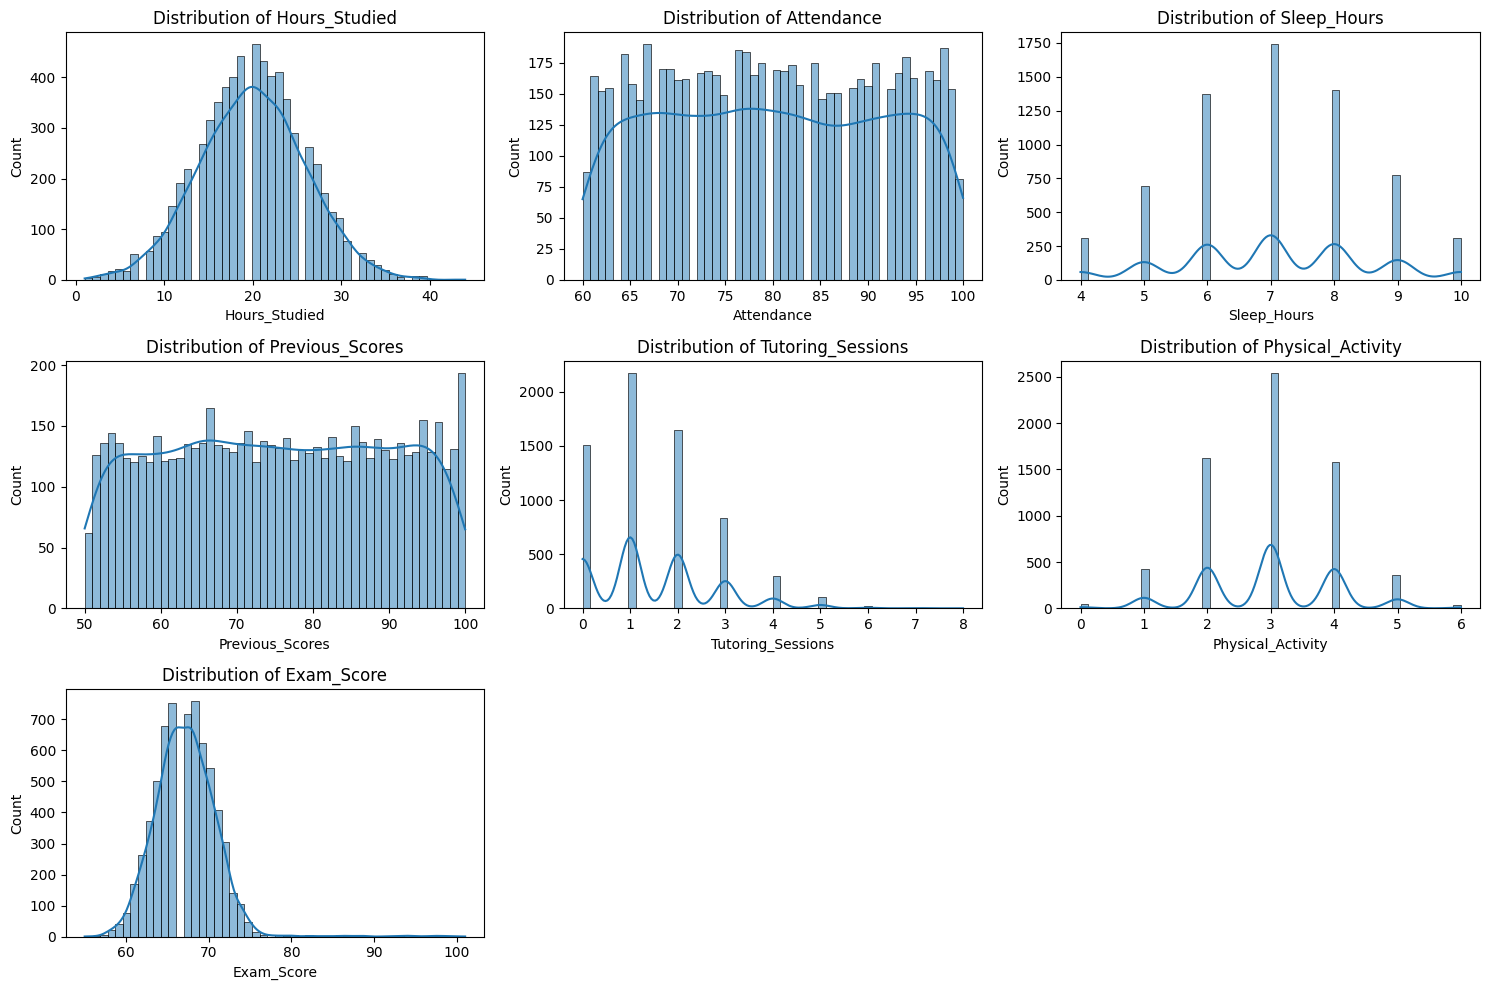

In [36]:
#Define Ukuran Plot
plt.figure(figsize=(15,10))
for i,col in enumerate(number_column,1):
    plt.subplot(3,3,i)
    sns.histplot(student_fix[col],bins=50,kde=True)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

#### Insight
* Sebagian Fitur terdistribusi secara normal (Peningkatan / Penurunan Stabil) sehingga jika data ini diterapkan sebagai fitur tidak akan membuat model menjadi overfitting (karena ada banyak variasi data)

#### Distribusi Nilai Kategorial dari Tiap Kolom

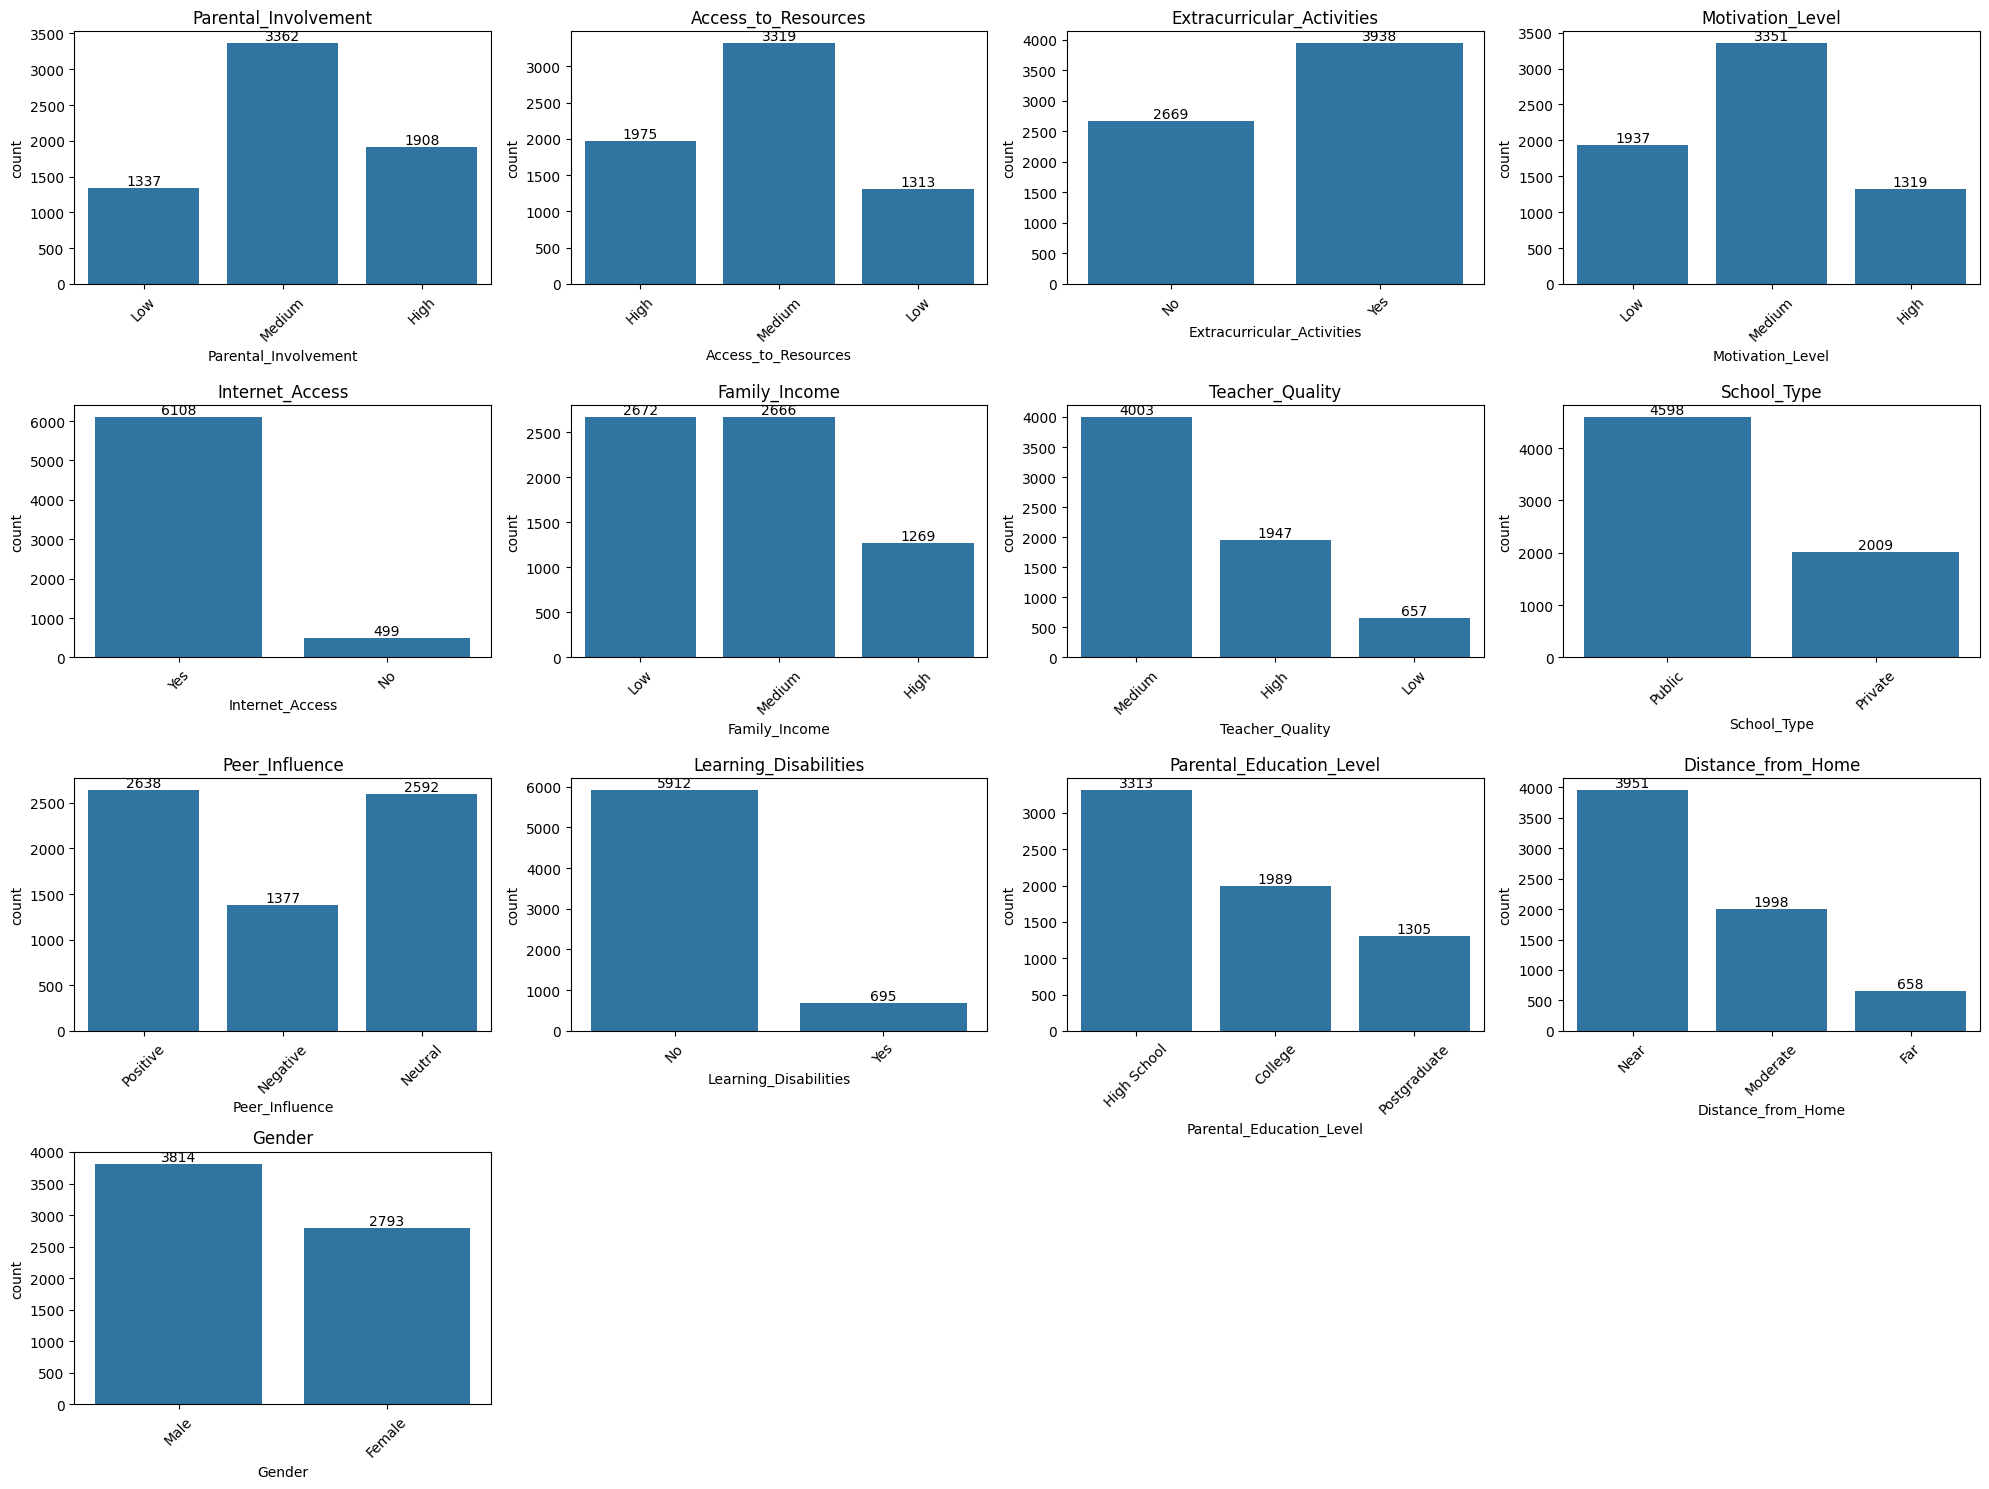

In [37]:
plt.figure(figsize=(20,15))
for i,col in enumerate(kategori_column,1):
    plt.subplot(4,4,i)
    ax = sns.countplot(data=student_fix,x=col)
    for container in ax.containers:
        ax.bar_label(container)
    plt.title(col)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Insight
* Sebagian siswa memiliki **parental involvement dan access to resource** dilevel **medium**
* Hampir 3/4 siswa memiliki **akses ke internet**
* Hampir 3/4 siswa tidak memiliki kendala selama belajar **(Learning_Disabilities)**
* Sebagian siswa memiliki **family income** di level low to medium
* Sebagian siswa memiliki **Parental education level** dari **High School**
* Terjadi Imbalance Class pada Target / Label **Motivation Level** sehingga perlu dilakukan penyeimbangan pada bagian training nanti **class_weight=balance**

#### Analisis Outlier Dari Tiap Kolom Bertipe Numerik

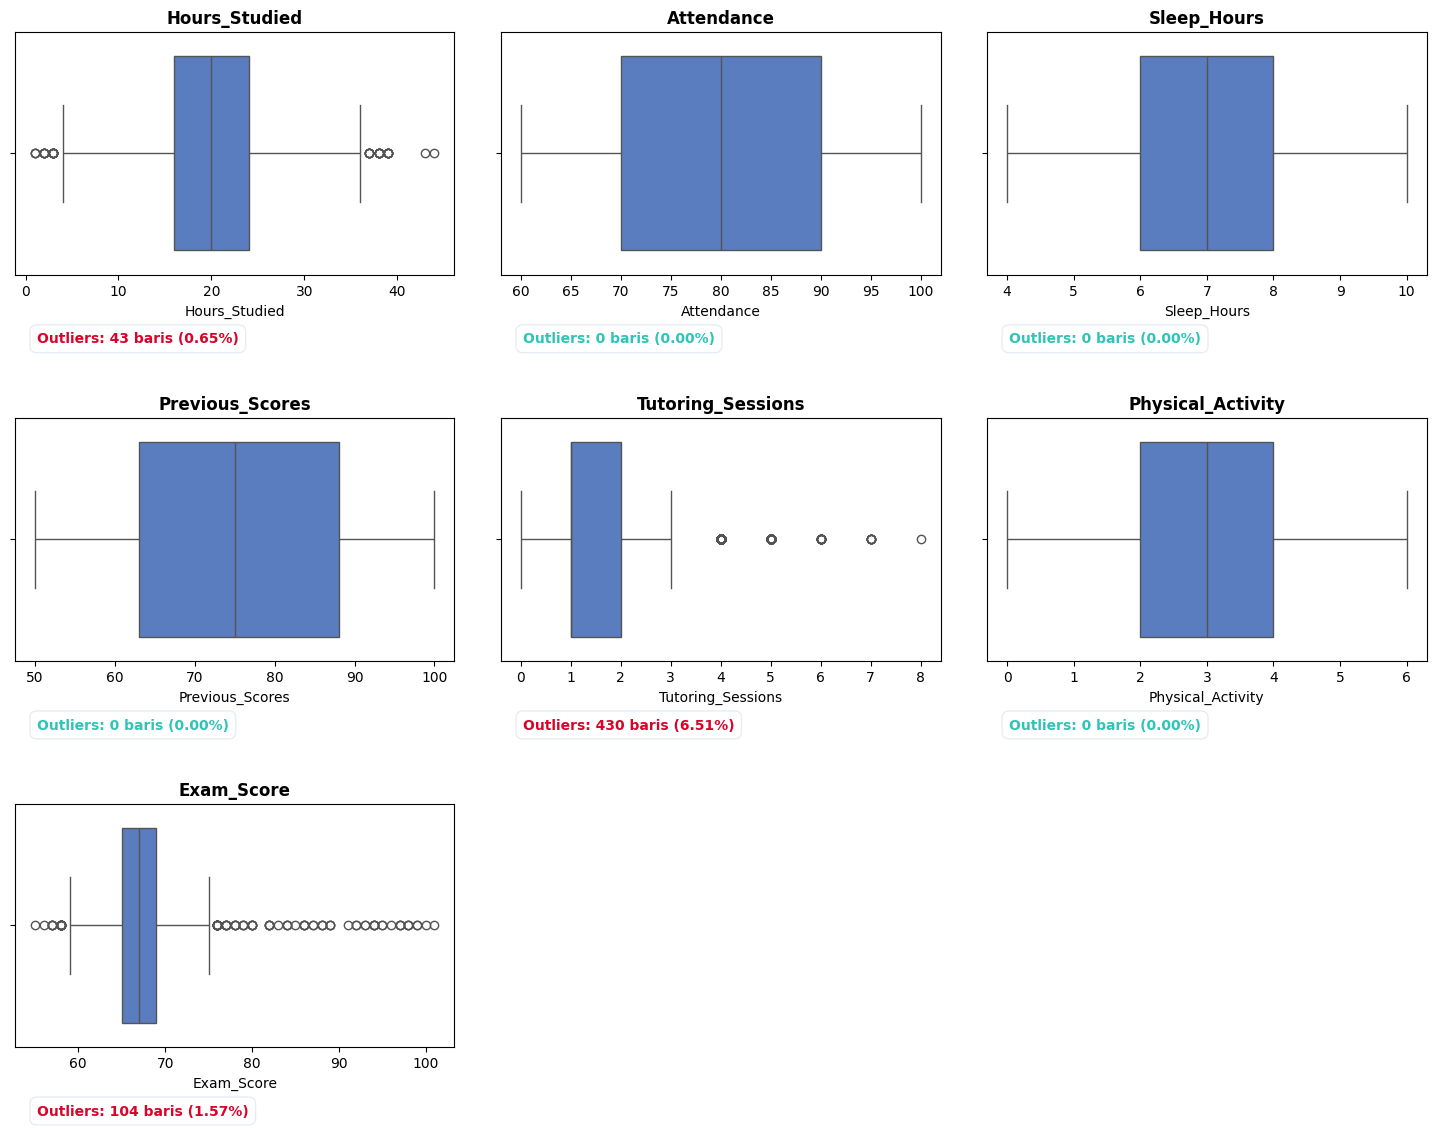

In [38]:
# Define Ukuran Plot Utama
plt.figure(figsize=(15, 12))
for i, col in enumerate(number_column, 1):
    ax = plt.subplot(3, 3, i)
    
    #Boxplot
    sns.boxplot(data=student_fix, x=col, ax=ax, palette="muted")
    plt.title(f"{col}", fontsize=12, fontweight='bold')
    
    #Outlier
    Q1 = student_fix[col].quantile(0.25)
    Q3 = student_fix[col].quantile(0.75)
    IQR = Q3 - Q1
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR
    
    total_outliers = len(student_fix[(student_fix[col] < batas_bawah) | (student_fix[col] > batas_atas)])
    persentase = (total_outliers / len(student_fix)) * 100
    
    #Teks ditiap kolom
    label_teks = f"Outliers: {total_outliers} baris ({persentase:.2f}%)"
    
    ax.text(0.05, -0.28, label_teks, 
            transform=ax.transAxes, 
            fontsize=10, 
            fontweight='bold',
            color='#d90429' if total_outliers > 0 else '#2ec4b6',
            bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5', edgecolor='#e2e8f0'))

#Padding antar elemen
plt.tight_layout(pad=3.0)
plt.show()

#### Insight
* Terdapat beberapa outlier pada kolom **Hours_Studied** dan **Tutoring_Sessions** (Exam_Score adalah hal yang akan diprediksi)
* Menurut scikit-learn, Ketika menerapkan linear logistic kita perlu menghapus outlier supaya datanya menjadi lebih seimbang
* **Exam_Score** tidak dihapus outliernya karena Tujuan utama Machine Learning adalah melatih model agar bisa menebak variasi di dunia nyata. Di dunia pendidikan nyata, siswa yang nilainya anjlok (rendah) atau melonjak (tinggi) itu bukan kesalahan data (error), melainkan realitas variasi kemampuan siswa. Jadi jika kita menghapus outlier dari Exam_Score ibaratnya kita memaksa label untuk buta terhadap variasi nyatanya

## =======================================================================

## Data Processing | Handle Outlier | Metric Korelasi Numerik | Encoding (Kategorial ke Numerik)

#### Menghapus Outlier dengan menggunakan IQR Method (Q1 dan Q3)

In [39]:
for col in number_column:
    if col == "Exam_Score":
        continue
    Q1 = student_fix[col].quantile(0.25)
    Q3 = student_fix[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - (1.5 * IQR)
    upper = Q3 + (1.5 * IQR)
    student_fix = student_fix[(student_fix[col] >= lower) & (student_fix[col] <= upper)]

#### Analisa Setelah Outlier Dihapus

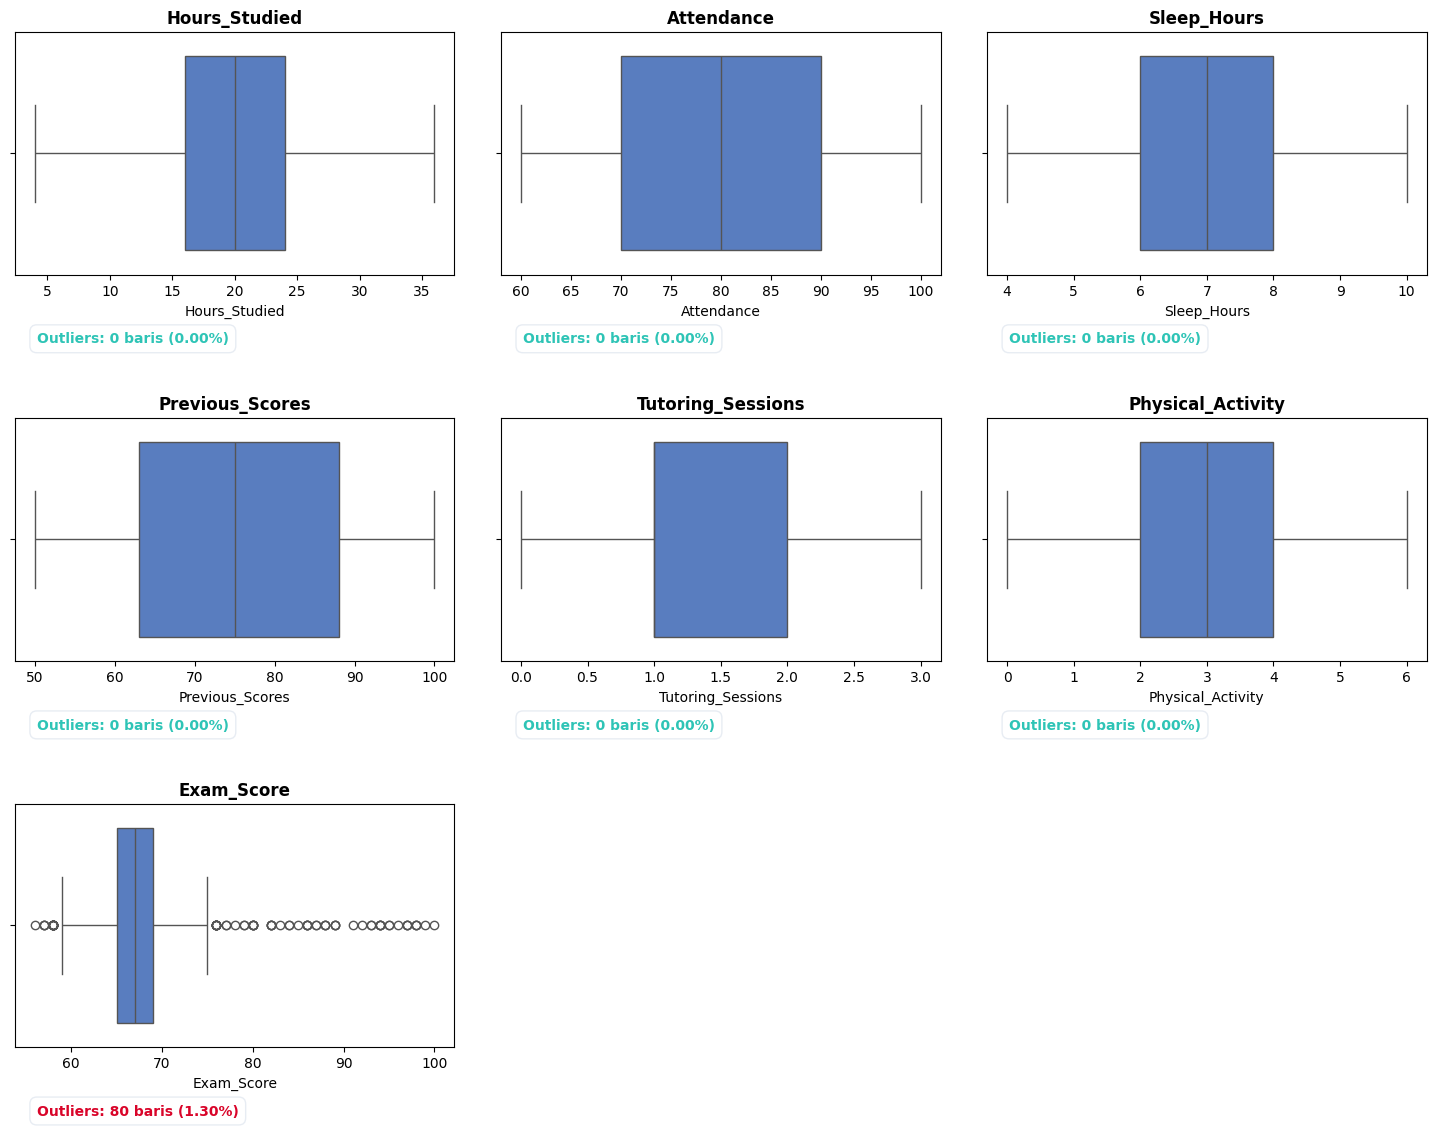

In [40]:
# Define Ukuran Plot Utama
plt.figure(figsize=(15, 12))
for i, col in enumerate(number_column, 1):
    ax = plt.subplot(3, 3, i)
    
    #Boxplot
    sns.boxplot(data=student_fix, x=col, ax=ax, palette="muted")
    plt.title(f"{col}", fontsize=12, fontweight='bold')
    
    #Outlier
    Q1 = student_fix[col].quantile(0.25)
    Q3 = student_fix[col].quantile(0.75)
    IQR = Q3 - Q1
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR
    
    total_outliers = len(student_fix[(student_fix[col] < batas_bawah) | (student_fix[col] > batas_atas)])
    persentase = (total_outliers / len(student_fix)) * 100
    
    #Teks ditiap kolom
    label_teks = f"Outliers: {total_outliers} baris ({persentase:.2f}%)"
    
    ax.text(0.05, -0.28, label_teks, 
            transform=ax.transAxes, 
            fontsize=10, 
            fontweight='bold',
            color='#d90429' if total_outliers > 0 else '#2ec4b6',
            bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5', edgecolor='#e2e8f0'))

#Padding antar elemen
plt.tight_layout(pad=3.0)
plt.show()

#### Insight
* Data (tipe numerik) sudah bersih dari outlier

#### Heatmap Korelasi Antar Tipe Data Numerik

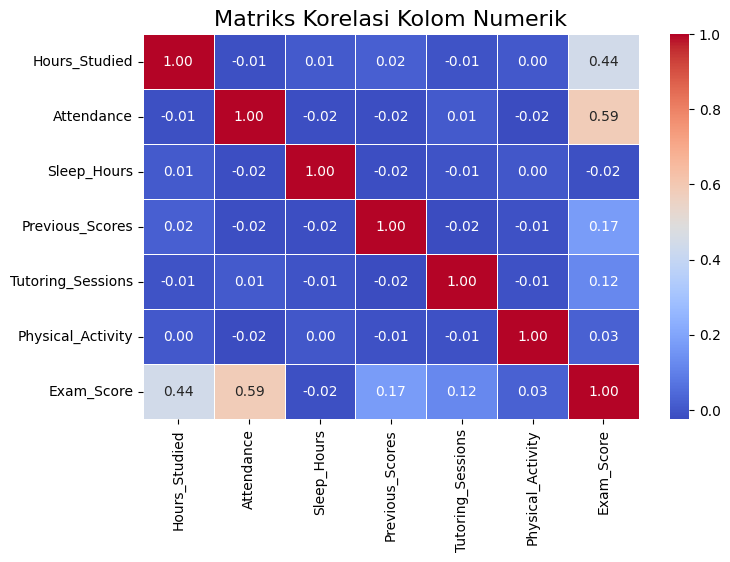

In [41]:
student_num = student_fix.select_dtypes(include=["int64"])
plt.figure(figsize=(8,5))
sns.heatmap(student_num.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriks Korelasi Kolom Numerik', fontsize=16)
plt.show()

#### Insight
* **Hours_Studied dan Attendance** memiliki korelasi dengan **Exam_Score** > 0.3 dengan nilai **0.44 dan 0.59**, sehingga **Hours_Studied dan Attendance** bisa digunakan sebagai fitur untuk Exam_Score

#### Ordinal Encoder ( Ubah Tipe Data Kategorial ke Numerik )

In [42]:
warning.filterwarnings('ignore')

#Kolom Kategorial
kategori_column = list(student_fix.select_dtypes(include=["object"]).columns)

#Ordinal Encoder
encoder = ["Parental_Involvement" ,"Access_to_Resources" ,"Motivation_Level" ,"Family_Income" ,"Teacher_Quality" ,"Peer_Influence" ,"Parental_Education_Level" ,"Distance_from_Home"]

ordinal_categories = [
    ["Low", "Medium", "High"],          # Parental_Involvement
    ["Low", "Medium", "High"],          # Access_to_Resources
    ["Low", "Medium", "High"],          # Motivation_Level
    ["Low", "Medium", "High"],          # Family_Income
    ["Low", "Medium", "High"],          # Teacher_Quality
    ["Negative", "Neutral", "Positive"],# Peer_Influence
    ["High School", "College", "Postgraduate"], # Parental_Education_Level
    ["Near", "Moderate", "Far"]         # Distance_from_Home
]

#Inisialisasi Ordinal Encoder | Kategori Bertingkat
ordinal_encoder = OrdinalEncoder(categories=ordinal_categories)

# Transform ordinal columns
student_fix[encoder] = ordinal_encoder.fit_transform(student_fix[encoder]).astype(int)

#Konversi One Hot Encoder
onehot = []
for enc in kategori_column:
    if enc not in encoder:
        onehot.append(enc)

#Konversi Final
student_fix = pd.get_dummies(student_fix, columns=onehot, drop_first=True, dtype=int)

#Debugging
baris, kolom = student_fix.shape
print(f"Baris : {baris} dan Kolom : {kolom}")
display(student_fix.head(10))
display(student_fix.tail(10))

Baris : 6134 dan Kolom : 20


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Family_Income,Teacher_Quality,Peer_Influence,Physical_Activity,Parental_Education_Level,Distance_from_Home,Exam_Score,Extracurricular_Activities_Yes,Internet_Access_Yes,School_Type_Public,Learning_Disabilities_Yes,Gender_Male
0,23,84,0,2,7,73,0,0,0,1,2,3,0,0,67,0,1,1,0,1
1,19,64,0,1,8,59,0,2,1,1,0,4,1,1,61,0,1,1,0,0
2,24,98,1,1,7,91,1,2,1,1,1,4,2,0,74,1,1,1,0,1
3,29,89,0,1,8,98,1,1,1,1,0,4,0,1,71,1,1,1,0,1
4,19,92,1,1,6,65,1,3,1,2,1,4,1,0,70,1,1,1,0,0
5,19,88,1,1,8,89,1,3,1,1,2,3,2,0,71,1,1,1,0,1
6,29,84,1,0,7,68,0,1,0,1,1,2,0,1,67,1,1,0,0,1
7,25,78,0,2,6,50,1,1,2,2,0,2,0,2,66,1,1,1,0,1
8,17,94,1,2,6,80,2,0,1,0,1,1,1,0,69,0,1,0,0,1
9,23,98,1,1,8,71,1,0,2,2,2,5,0,1,72,1,1,1,0,1


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Family_Income,Teacher_Quality,Peer_Influence,Physical_Activity,Parental_Education_Level,Distance_from_Home,Exam_Score,Extracurricular_Activities_Yes,Internet_Access_Yes,School_Type_Public,Learning_Disabilities_Yes,Gender_Male
6597,16,91,2,1,6,72,2,0,2,2,0,2,2,0,70,1,1,1,0,0
6598,9,87,0,1,6,64,1,1,2,1,1,2,0,0,64,1,1,1,0,0
6599,30,94,1,0,5,52,0,3,2,1,1,2,2,1,70,0,0,0,0,0
6600,12,98,1,0,4,54,1,2,1,2,1,3,0,0,67,1,1,0,0,0
6601,20,83,1,0,6,51,0,2,1,1,1,4,0,1,65,0,1,1,0,0
6602,25,69,2,1,7,76,1,1,2,1,2,2,0,0,68,0,1,1,0,0
6603,23,76,2,1,8,81,1,3,0,2,2,2,0,0,69,0,1,1,0,0
6604,20,90,1,0,6,65,0,3,0,1,0,2,2,0,68,1,1,1,0,0
6605,10,86,2,2,6,91,2,2,0,1,2,3,0,2,68,1,1,0,0,0
6606,15,67,1,0,9,94,1,0,1,1,2,4,2,0,64,1,1,1,0,1


### Mean , Median dan Modus Setelah Di Encoding dari Tiap Kolom Dataset

In [43]:
student_fix.describe()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Family_Income,Teacher_Quality,Peer_Influence,Physical_Activity,Parental_Education_Level,Distance_from_Home,Exam_Score,Extracurricular_Activities_Yes,Internet_Access_Yes,School_Type_Public,Learning_Disabilities_Yes,Gender_Male
count,6134.000000,6134.000000,6134.000000,6134.000000,6134.000000,6134.000000,6134.000000,6134.000000,6134.000000,6134.000000,6134.000000,6134.000000,6134.000000,6134.000000,6134.000000,6134.000000,6134.000000,6134.000000,6134.000000,6134.000000
mean,20.000163,79.935116,1.088523,1.099609,7.033420,75.085915,0.905608,1.291164,0.787251,1.197261,1.191392,2.957450,0.696772,0.502934,67.130584,0.595533,0.923215,0.696772,0.104173,0.576622
std,5.818509,11.533334,0.693889,0.698481,1.468854,14.368719,0.695932,0.983807,0.741643,0.596653,0.755145,1.031534,0.780280,0.671014,3.821861,0.490829,0.266272,0.459690,0.305510,0.494134
min,4.000000,60.000000,0.000000,0.000000,4.000000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,56.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,70.000000,1.000000,1.000000,6.000000,63.000000,0.000000,1.000000,0.000000,1.000000,1.000000,2.000000,0.000000,0.000000,65.000000,0.000000,1.000000,0.000000,0.000000,0.000000
50%,20.000000,80.000000,1.000000,1.000000,7.000000,75.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,0.000000,0.000000,67.000000,1.000000,1.000000,1.000000,0.000000,1.000000
75%,24.000000,90.000000,2.000000,2.000000,8.000000,88.000000,1.000000,2.000000,1.000000,2.000000,2.000000,4.000000,1.000000,1.000000,69.000000,1.000000,1.000000,1.000000,0.000000,1.000000
max,36.000000,100.000000,2.000000,2.000000,10.000000,100.000000,2.000000,3.000000,2.000000,2.000000,2.000000,6.000000,2.000000,2.000000,100.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Matriks Korelasi Seluruh Fitur

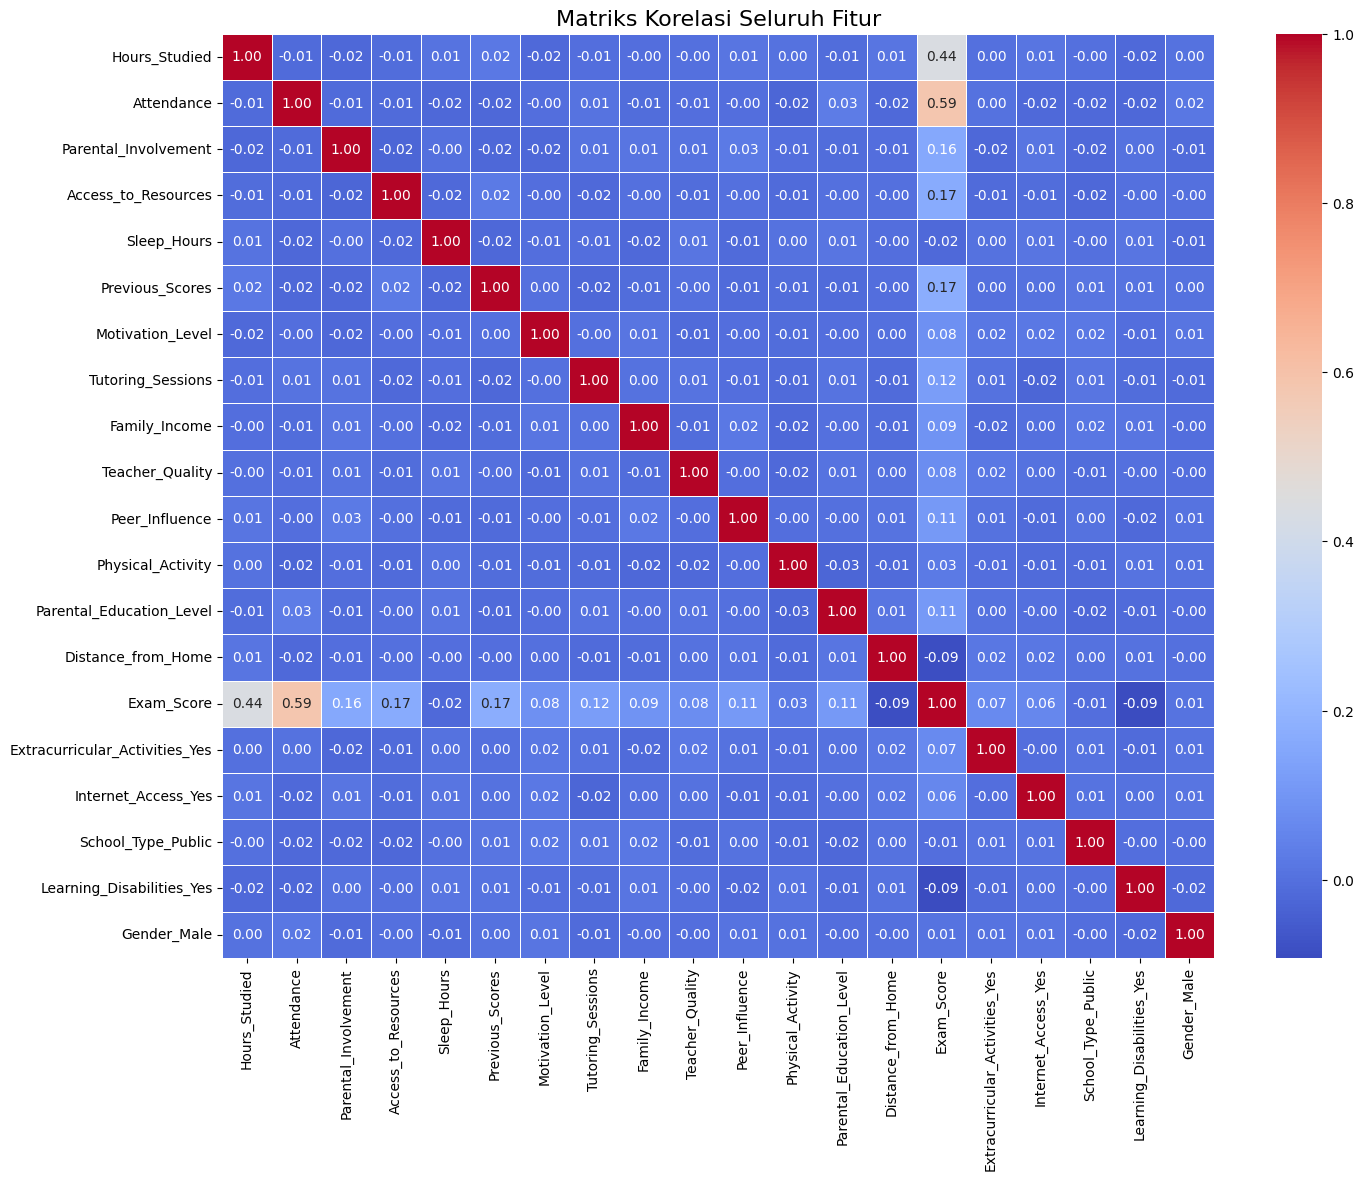

In [44]:
plt.figure(figsize=(16, 12))
sns.heatmap(student_fix.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriks Korelasi Seluruh Fitur', fontsize=16)
plt.show()

### Matriks Korelasi Dengan Target Exam Score

Exam_Score                        1.000000
Attendance                        0.586113
Hours_Studied                     0.440121
Previous_Scores                   0.173492
Access_to_Resources               0.165539
Parental_Involvement              0.156052
Tutoring_Sessions                 0.123321
Parental_Education_Level          0.111370
Peer_Influence                    0.110321
Family_Income                     0.093905
Motivation_Level                  0.083042
Teacher_Quality                   0.077367
Extracurricular_Activities_Yes    0.066318
Internet_Access_Yes               0.059043
Physical_Activity                 0.025439
Gender_Male                       0.008731
School_Type_Public               -0.005115
Sleep_Hours                      -0.016404
Distance_from_Home               -0.087095
Learning_Disabilities_Yes        -0.092228
Name: Exam_Score, dtype: float64

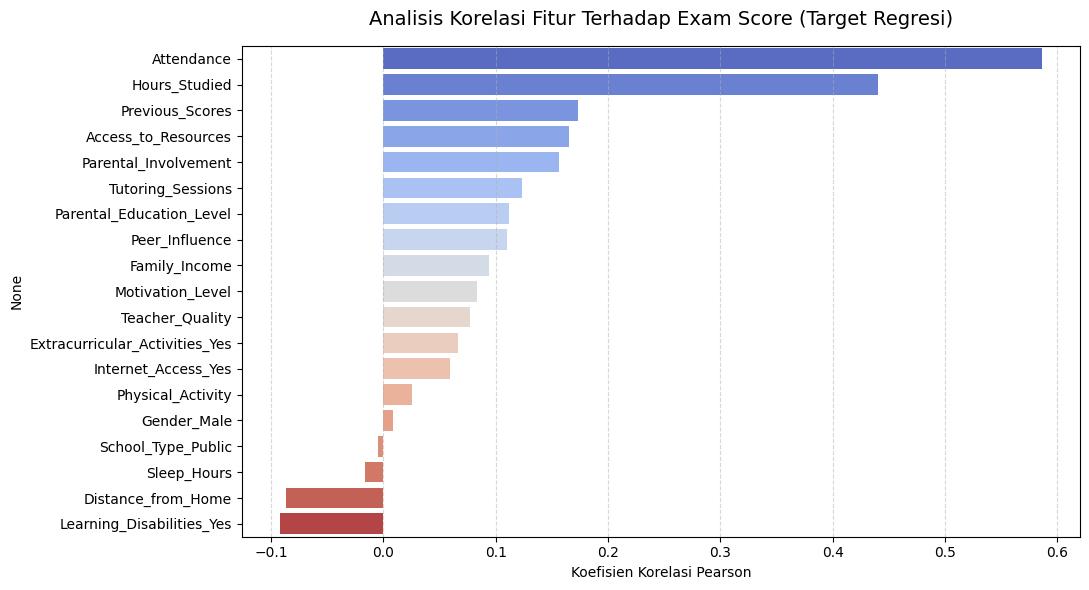

In [45]:
# Lihat korelasi semua fitur terhadap Exam Score
korelasi = student_fix.corr()['Exam_Score'].sort_values(ascending=False)
display(korelasi)

plt.figure(figsize=(11, 6))
sns.barplot(x=korelasi.drop('Exam_Score').values, y=korelasi.drop('Exam_Score').index, palette='coolwarm')
plt.title('Analisis Korelasi Fitur Terhadap Exam Score (Target Regresi)', fontsize=14, pad=15)
plt.xlabel('Koefisien Korelasi Pearson')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Matriks Korelasi Dengan Target Motivation Level

Motivation_Level                  1.000000
Exam_Score                        0.083042
Internet_Access_Yes               0.022474
School_Type_Public                0.020097
Extracurricular_Activities_Yes    0.017573
Family_Income                     0.013211
Gender_Male                       0.010367
Previous_Scores                   0.000436
Distance_from_Home                0.000070
Tutoring_Sessions                -0.001290
Parental_Education_Level         -0.002873
Access_to_Resources              -0.003128
Attendance                       -0.003323
Peer_Influence                   -0.003780
Learning_Disabilities_Yes        -0.005126
Sleep_Hours                      -0.005846
Physical_Activity                -0.008321
Teacher_Quality                  -0.012874
Hours_Studied                    -0.018519
Parental_Involvement             -0.023550
Name: Motivation_Level, dtype: float64

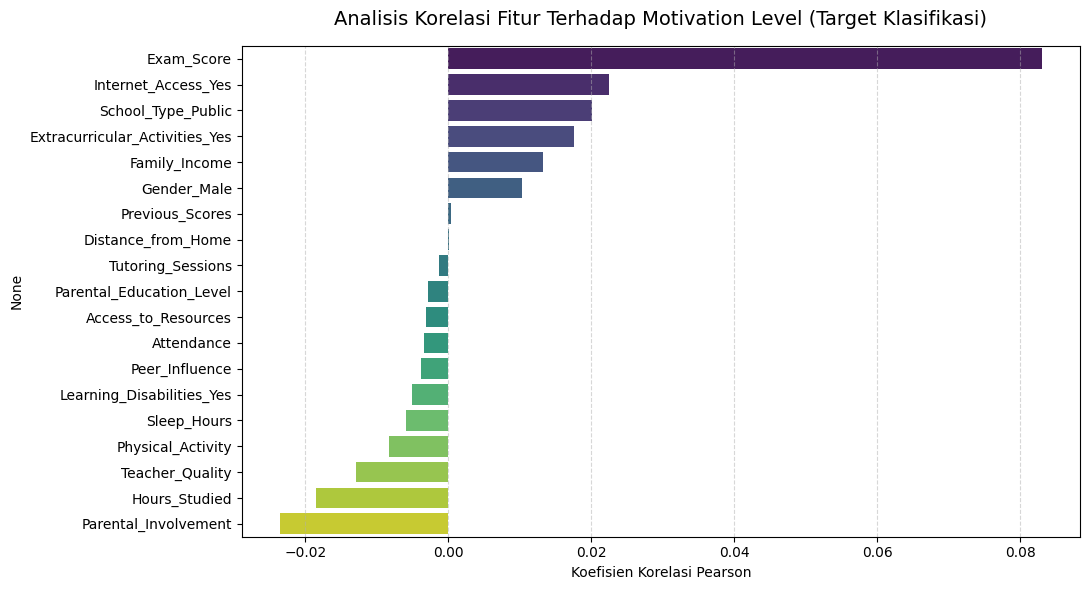

In [46]:
# Lihat korelasi semua fitur terhadap Motivation_Level
korelasi = student_fix.corr()['Motivation_Level'].sort_values(ascending=False)
display(korelasi)

plt.figure(figsize=(11, 6))
sns.barplot(x=korelasi.drop('Motivation_Level').values, y=korelasi.drop('Motivation_Level').index, palette='viridis')
plt.title('Analisis Korelasi Fitur Terhadap Motivation Level (Target Klasifikasi)', fontsize=14, pad=15)
plt.xlabel('Koefisien Korelasi Pearson')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### **Analisis Korelasi terhadap Target Klasifikasi (`Motivation_Level`)**

Berdasarkan perhitungan korelasi Pearson di atas, kita dapat menarik *insight* yang sangat krusial terkait karakteristik dataset:

1. **Ketiadaan Hubungan Linier:** Seluruh fitur independen memiliki nilai korelasi yang sangat lemah, yakni berada di rentang **-0.023 hingga 0.083** (mendekati 0). 
2. **Karakteristik Data Psikologis:** Hal ini membuktikan bahwa tingkat motivasi siswa (`Motivation_Level`) tidak dipengaruhi secara linier oleh satu metrik numerik tertentu (seperti jam belajar atau jumlah sesi les). Motivasi merupakan variabel psikologis yang sifatnya kompleks dan non-linier.
3. **Implikasi pada Pemilihan Fitur (Feature Selection):** Karena metode seleksi fitur berbasis statistik murni (seperti mengambil korelasi tertinggi) tidak dapat diterapkan secara efektif pada target ini, maka tahap pemodelan klasifikasi nantinya **wajib menggunakan pendekatan Domain Knowledge**. Kita akan memilih fitur berdasarkan logika kependidikan dan teori psikologi sosial (seperti peran keluarga, pengaruh teman sebaya, dan akses fasilitas) sehingga tidak bergantung pada korelasi

### **Pemilihan Fitur (Feature Selection) untuk Model Klasifikasi Motivasi**

Berdasarkan hasil analisis korelasi Pearson pada tahap EDA, diketahui bahwa seluruh atribut independen memiliki korelasi linier yang sangat rendah (mendekati 0) terhadap target `Motivation_Level`. 

Oleh karena itu, pemilihan fitur untuk model *Logistic Regression* ini tidak dilakukan secara statistik, melainkan menggunakan pendekatan **Domain Knowledge** (Teori Kependidikan). Fitur-fitur yang dipilih adalah:
1. `Parental_Involvement`
2. `Access_to_Resources`
3. `Family_Income`
4. `Teacher_Quality`
5. `Peer_Influence`
6. `Previous_Scores`

**Alasan:** Keenam fitur di atas merupakan prediktor psikologis dan lingkungan (sosial, ekonomi, dan fasilitas) yang secara teori dunia nyata paling kuat dalam membentuk motivasi internal seorang siswa.

## =======================================================================

## Training Model

#### Train Test Split | Training Linear Regression Exam Score | Metric Accuracy

In [47]:
#Split X dan Y (X -> Fitur dan Y -> Target)
# 5 Fitur Terbaik Sesuai Korelasi Matriks
fitur_pilihan = ['Hours_Studied', 'Attendance', 'Previous_Scores', 'Parental_Involvement', 'Access_to_Resources']
x = student_fix[fitur_pilihan]
y = student_fix["Exam_Score"]

display(x.head(3))

#Model
model_linear = LinearRegression()

# Split Training
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

model_linear.fit(x_train, y_train)
predict = model_linear.predict(x_test)

print("===================================================================")

# R2 Score
r2 = r2_score(y_test, predict)
print("R2 Score Linear Regression :", round(r2, 2))

# MAE
mae = mean_absolute_error(y_test, predict)
print("Mean Absolute Error (MAE) Linear Regression:", round(mae, 2), "poin")

print("===================================================================")

,Hours_Studied,Attendance,Previous_Scores,Parental_Involvement,Access_to_Resources
0,23,84,73,0,2
1,19,64,59,0,1
2,24,98,91,1,1


R2 Score Linear Regression : 0.68
Mean Absolute Error (MAE) Linear Regression: 1.06 poin


#### Prediksi Vs Actual ( Hasil Training )

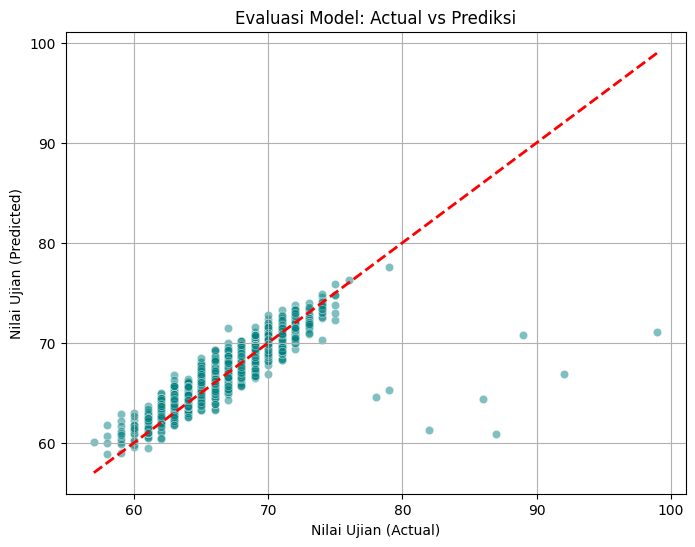

In [48]:
#Define Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=predict, alpha=0.5, color='teal')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', lw=2)

plt.title('Evaluasi Model: Actual vs Prediksi')
plt.xlabel('Nilai Ujian (Actual)')
plt.ylabel('Nilai Ujian (Predicted)')
plt.grid(True)
plt.show()

#### **Analisis dan Interpretasi Hasil Evaluasi Linear Regression**

Berdasarkan proses pelatihan model *Linear Regression* menggunakan 5 fitur terbaik (`Hours_Studied`, `Attendance`, `Previous_Scores`, `Parental_Involvement`, `Access_to_Resources`), diperoleh hasil evaluasi sebagai berikut:

**1. R-Squared ($R^2$) Score: 0.68 (68%)**
* **Arti:** Model yang dibangun mampu menjelaskan **68%** varians atau perubahan dari nilai ujian siswa (`Exam_Score`). 
* **Interpretasi:** Nilai ini tergolong **cukup baik** untuk dataset yang melibatkan perilaku manusia (akademik). Hal ini berarti kombinasi dari jam belajar, kehadiran, nilai masa lalu, dukungan orang tua, dan akses fasilitas memiliki pengaruh sebesar 68% terhadap nilai ujian akhir. Sisa 32% lainnya dipengaruhi oleh faktor-faktor eksternal yang tidak ditangkap oleh 5 fitur ini (misalnya kondisi psikologis saat ujian, kesehatan, dll).

**2. Mean Absolute Error (MAE): 1.06 Poin**
* **Arti:** Secara rata-rata, prediksi nilai ujian yang dihasilkan oleh model meleset sebesar **1,06 poin** dari nilai ujian aslinya.
* **Interpretasi:** Nilai error ini **sangat kecil dan sangat baik**. Sebagai ilustrasi, jika seorang siswa seharusnya mendapatkan nilai ujian asli `85`, model diprediksi akan menebak di kisaran `83.94` hingga `86.06`. Dalam konteks penilaian akademik, margin kesalahan sekitar 1 poin sangat bisa ditoleransi dan membuktikan bahwa model ini memiliki tingkat presisi prediktif yang tinggi di dunia nyata.

**Kesimpulan:**
Penggunaan 5 fitur teratas hasil analisis korelasi terbukti efektif menghasilkan model prediksi nilai ujian yang stabil dan akurat, tanpa mengalami *overfitting* yang sering terjadi jika memasukkan terlalu banyak fitur yang tidak relevan.

#### Train Test Split | Training Logistic Regression Motivation Level | Metric Accuracy

Accuracy Score Logistic Regression : 0.38

Detail Performa Tiap Tingkat Motivasi:
              precision    recall  f1-score   support

           0       0.29      0.38      0.33       357
           1       0.57      0.40      0.47       644
           2       0.23      0.31      0.26       226

    accuracy                           0.38      1227
   macro avg       0.36      0.36      0.35      1227
weighted avg       0.42      0.38      0.39      1227



<Figure size 800x600 with 0 Axes>

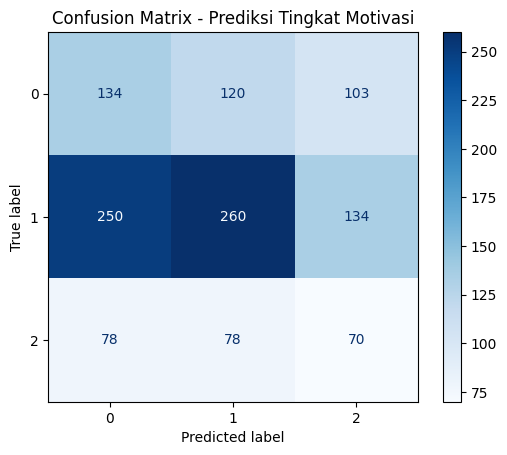

In [49]:
#Split X dan Y (X -> Fitur dan Y -> Target)
fitur_motivasi = ['Parental_Involvement', 'Access_to_Resources', 'Family_Income', 'Teacher_Quality', 'Peer_Influence', 'Previous_Scores']
x = student_fix[fitur_motivasi]
y = student_fix["Motivation_Level"]

#Model
model_logistic = LogisticRegression(max_iter=500, random_state=10, class_weight="balanced")

#Split Training
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

#Scaller Data 
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

model_logistic.fit(x_train, y_train)
predict = model_logistic.predict(x_test)

print("===================================================================")
#Akurasi Skor
print("Accuracy Score Logistic Regression :", round(accuracy_score(y_test, predict), 2))

#Classification Report
print("\nDetail Performa Tiap Tingkat Motivasi:")
print(classification_report(y_test, predict))

cm = confusion_matrix(y_test, predict)
label_kelas = model_logistic.classes_ 

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_kelas)

disp.plot(cmap='Blues', values_format='d') 

plt.title('Confusion Matrix - Prediksi Tingkat Motivasi')
plt.grid(False)
plt.show()

print("===================================================================")

### **Analisis dan Interpretasi Hasil Evaluasi Logistic Regression**

Berdasarkan proses pelatihan model klasifikasi *Logistic Regression* menggunakan fitur berbasis *Domain Knowledge* untuk memprediksi `Motivation_Level` (0 = Low, 1 = Medium, 2 = High), diperoleh hasil evaluasi sebagai berikut:

**1. Akurasi Model (Accuracy Score): 0.38 (38%)**
* **Interpretasi:** Model hanya mampu menebak tingkat motivasi siswa dengan benar sebesar 38%. Karena target memiliki 3 kelas (Low, Medium, High), peluang tebakan acak (*random baseline*) adalah sekitar 33.3%. Akurasi 38% menunjukkan bahwa model ini **hanya sedikit lebih baik daripada menebak secara acak/mengundi**.
* **Alasan Keterbatasan:** Hasil ini sangat konsisten dan sudah diprediksi sejak awal pada tahap **Analisis Korelasi (EDA)**. Ketiadaan korelasi linier antara fitur manapun terhadap `Motivation_Level` membuat algoritma linier seperti *Logistic Regression* kesulitan menarik garis pembatas (*decision boundary*) yang jelas untuk memisahkan ketiga kelas tersebut.

**2. Detail Performa Kelas (Classification Report & Confusion Matrix):**
* **Kelas 1 (Medium - Mayoritas):** Memiliki nilai *F1-Score* tertinggi (0.47) dan presisi terbaik (0.57). Hal ini wajar karena distribusi data dari awal memang didominasi oleh kelas *Medium* (dukungan/support data mencapai 644 baris di set pengujian).
* **Kelas 0 (Low) & Kelas 2 (High):** Memiliki performa yang sangat rendah (F1-score 0.33 dan 0.26). Penggunaan parameter `class_weight="balanced"` pada model sudah membantu menaikkan persentase *Recall* (kepekaan model), namun karena datanya sendiri tidak memiliki pola pembeda yang jelas, model tetap sering salah menebak (misalnya, siswa yang aslinya motivasi *High* malah ditebak *Medium* atau *Low*).

**Kesimpulan Akhir Pemodelan Klasifikasi:**
Akurasi yang rendah pada model ini **bukanlah kegagalan proses Machine Learning**, melainkan sebuah temuan analitik yang penting. Hal ini membuktikan bahwa metrik-metrik fisik dan fasilitas (seperti pendapatan keluarga, akses fasilitas, dan dukungan orang tua) di dalam dataset ini **tidak cukup informatif** untuk memetakan kondisi psikologis siswa (Tingkat Motivasi). Untuk memprediksi motivasi secara akurat, diperlukan jenis data yang berbeda, seperti kuesioner psikologis, tes kepribadian, atau wawancara emosional.

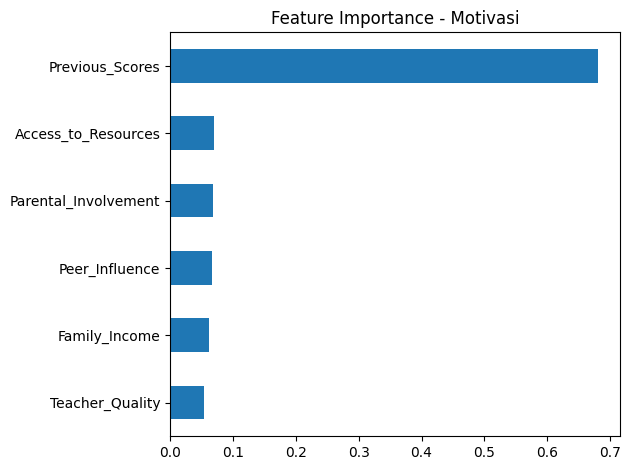

In [50]:
model_rf = RandomForestClassifier(n_estimators=200, random_state=10, class_weight='balanced')
model_rf.fit(x_train, y_train)

# Visualisasi Feature Important
importances = pd.Series(model_rf.feature_importances_, index=fitur_motivasi)
importances.sort_values().plot(kind='barh', title='Feature Importance - Motivasi')
plt.tight_layout()
plt.show()

##### Accuracy_Score kurang bagus diangka 0.38 namun jika dilihat dari hasil recall (hasil tebakan) menandakan bahwa sudah bagus karena berhasil menebak meskipun dengan presentase kebenaran yang kurang bagus
### Insight Feature Importance

Random Forest menempatkan Previous_Scores sebagai fitur paling dominan (~68%),
namun berdasarkan analisis korelasi sebelumnya, nilai korelasinya terhadap
Motivation_Level hanya r = 0.0004 — mendekati nol.

Hal ini mengindikasikan model mengalami kesulitan menemukan pola yang bermakna.
Dominasi Previous_Scores kemungkinan bukan karena fitur ini prediktif secara
nyata, melainkan karena fitur lain bahkan lebih tidak informatif.

Kesimpulan: Dataset ini tidak dirancang untuk memprediksi Motivation_Level
secara akurat. Akurasi 37-38% (di atas random baseline 33%) menunjukkan model
masih sedikit lebih baik dari tebakan acak, namun keterbatasan data adalah
faktor utama, bukan kualitas model.

## =======================================================================

#### Export Model

In [ ]:
import joblib

joblib.dump(model_linear, 'model_linear_exam.pkl')
joblib.dump(model_logistic, 'model_logistic_motivation.pkl')
joblib.dump(scaler, 'scaler_model.pkl')

## =======================================================================
## BAB KESIMPULAN AKHIR & REKOMENDASI
## =======================================================================

Berdasarkan seluruh tahapan *Machine Learning* yang telah dilakukan, mulai dari *Exploratory Data Analysis* (EDA), *Preprocessing*, hingga *Modeling* dan Evaluasi pada dataset *Student Performance Factors*, dapat ditarik kesimpulan akhir sebagai berikut:

### **1. Kesimpulan Pemodelan Regresi (`Exam_Score`)**
* **Performa Sangat Baik:** Model *Linear Regression* berhasil memprediksi nilai ujian siswa dengan cukup presisi. Penggunaan 5 fitur terbaik (seperti `Hours_Studied` dan `Attendance`) menghasilkan **R2 Score sebesar 0.68** dan margin kesalahan rata-rata (**MAE**) yang sangat kecil, yaitu hanya **1.06 poin**. 
* **Karakteristik Data:** Hal ini membuktikan bahwa atribut fisik, durasi belajar, dan kedisiplinan kehadiran dalam dataset ini memiliki hubungan linier yang sangat kuat dan relevan untuk memprediksi capaian akademik kognitif siswa.

### **2. Kesimpulan Pemodelan Klasifikasi (`Motivation_Level`)**
* **Limitasi Prediktif Data:** Berkebalikan dengan nilai ujian, tingkat motivasi terbukti tidak dapat diprediksi menggunakan atribut dalam dataset ini. Model *Logistic Regression* tertahan di **Akurasi 38%** (hanya 5% di atas *random baseline* 33%). 
* **Insight Feature Importance:** Analisis *Feature Importance* dari *Random Forest* semakin memperkuat fakta ini. Model terpaksa menempatkan `Previous_Scores` sebagai fitur paling dominan (~68%) bukan karena fitur tersebut memiliki korelasi yang kuat (korelasi aktualnya hanya $r = 0.0004$), melainkan karena fitur-fitur lainnya jauh lebih tidak informatif (mendekati *noise*).
* **Bukan Kegagalan Model:** Rendahnya metrik *Accuracy* dan *Recall* bukanlah indikasi kegagalan algoritma, melainkan fakta objektif bahwa kondisi psikologis (motivasi) bersifat non-linier dan kompleks.